LOAD DATA

In [1]:
import pandas as pd
df=pd.read_csv("C:\\Users\\HP\\OneDrive\\文档\\Python_for_Porto\\-regression\\data_task3.csv")
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


EDA DAN PREPROCESSING DATA

In [2]:
df.shape
#mengetahui jumlah baris dan kolom dataset

(205, 26)

In [3]:
df.info()
#mengetahui tipe data masing-masing atribut dalam dataset
#insight: ada beberapa atribut yang seharusnya numeric namun terdeteksi object, pennyebab karena ada value "?". perlu penanganan

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [4]:
import numpy as np

df.replace("?", np.nan, inplace=True)
#mengubah value "?" (string) sebagai NaN agar mudah dideteksi missing value

In [5]:
df.isnull().sum()
#mengetahui jumlah null value masing-masing atribut
#insight: atribut "normalized-losses" mempunyai missing value paling banyak

symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64

In [6]:
num_cols = ["normalized-losses", "bore", "stroke",
            "horsepower", "peak-rpm", "price"]

cat_cols = [col for col in df.columns if col not in num_cols]

#memisahkan atribut kategorik dan numeric

In [7]:
for col in num_cols:
    df[col] = pd.to_numeric(df[col])

#mengubah atribut num yang masih object menjadi float agar mudah dianalisis

In [8]:
df.info()
#cek kembali tipe data memastikan sesuai dengan data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       203 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [9]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Percentage": missing_percent
})

missing_df.sort_values(by="Percentage", ascending=False)

#menghitung presentase missing value untuk mempertimbangkan penanganan missing value
#insight: missing value memiliki presentase dibawah 30%, penanganan rekomendasi imputasi

,Missing Count,Percentage
normalized-losses,41,20.00000
stroke,4,1.95122
price,4,1.95122
bore,4,1.95122
horsepower,2,0.97561
peak-rpm,2,0.97561
num-of-doors,2,0.97561
symboling,0,0.00000
fuel-type,0,0.00000
make,0,0.00000


In [ ]:
df.skew(numeric_only=True)
#mengecek distribusi atribut num untuk menentukan jenis imputasi yang sesuai (skew (< -0.5 atau > 0.5): median, normal (-0.5 s/d 0.5): mean)
#insight: atribut "normalized-losses", "stroke", "horsepower" memiliki distribusi skew sehingga penanganan dengan imputasi median, sedangkan atribut bore", "peak-rpm" berdistribusi mormal sehingga penagnagn imputasi mean

symboling            0.211072
normalized-losses    0.765976
wheel-base           1.050214
length               0.155954
width                0.904003
height               0.063123
curb-weight          0.681398
engine-size          1.947655
bore                 0.020016
stroke              -0.683122
compression-ratio    2.610862
horsepower           1.391029
peak-rpm             0.073237
city-mpg             0.663704
highway-mpg          0.539997
price                1.809675
dtype: float64

array([[<Axes: title={'center': 'normalized-losses'}>,
        <Axes: title={'center': 'bore'}>],
       [<Axes: title={'center': 'stroke'}>,
        <Axes: title={'center': 'horsepower'}>],
       [<Axes: title={'center': 'peak-rpm'}>,
        <Axes: title={'center': 'price'}>]], dtype=object)

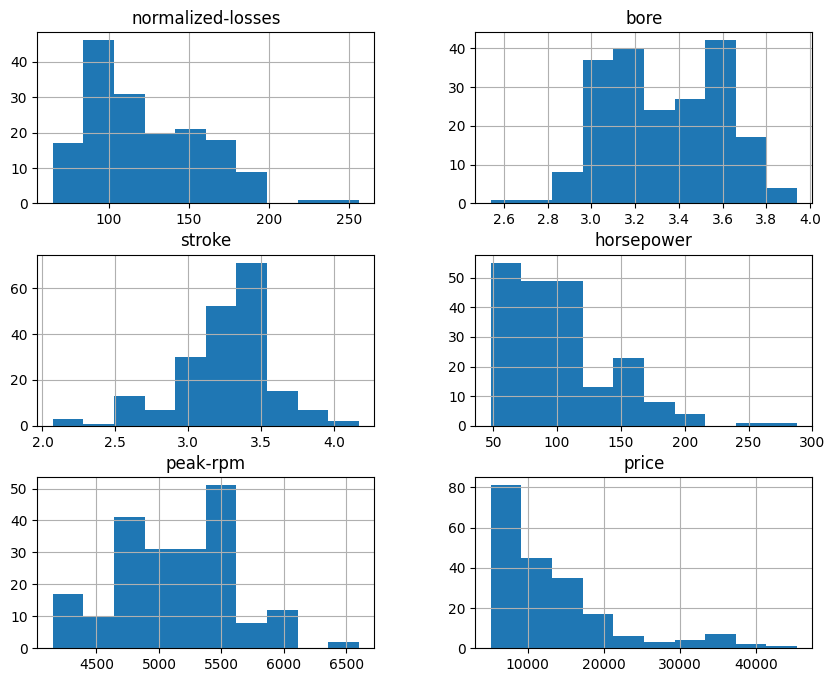

In [ ]:
df[num_cols].hist(figsize=(10,8))
#visualisasinya distribusi atribut num

In [12]:
df["normalized-losses"] = df["normalized-losses"].fillna(df["normalized-losses"].median())
df["stroke"] = df["stroke"].fillna(df["stroke"].median())
df["horsepower"] = df["horsepower"].fillna(df["horsepower"].median())
#penanganan missing value dengan median

df["bore"] = df["bore"].fillna(df["bore"].mean())
df["peak-rpm"] = df["peak-rpm"].fillna(df["peak-rpm"].mean())
#penanganan missing value dengan mean

df["num-of-doors"] = df["num-of-doors"].fillna(df["num-of-doors"].mode()[0])
#penanganan missing value pada atribut kategori dengan modus

df = df.dropna(subset=["price"])
#penanganan missing value pada atribut target dengan hapus karena value pada atribut target tidak boleh kosong atau ditebak agar data belajar dengan akurat

In [13]:
df.describe()
#mengetahui rangkuman statistik atribut numeric

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.840796,120.711443,98.797015,174.200995,65.889055,53.766667,2555.666667,126.875622,3.330692,3.257562,10.164279,103.313433,5117.665368,25.179104,30.686567,13207.129353
std,1.254802,32.111623,6.066366,12.322175,2.101471,2.447822,517.296727,41.546834,0.268072,0.316082,4.004965,37.374942,478.113805,6.423220,6.815150,7947.066342
min,-2.000000,65.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,101.000000,94.500000,166.800000,64.100000,52.000000,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,115.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5125.369458,24.000000,30.000000,10295.000000
75%,2.000000,137.000000,102.400000,183.500000,66.600000,55.500000,2926.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,256.000000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000


In [14]:
df.isnull().sum()
#mengetahui jumlah missing value masing-masing atribut
#insight: tidak ada missing value

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

In [15]:
df.duplicated().sum()
#mengetahui data duplikat
#insight: tidak ada data duplikat

np.int64(0)

In [16]:
df.columns
#mengetahui atribut yang ada pada dataset

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price'],
      dtype='object')

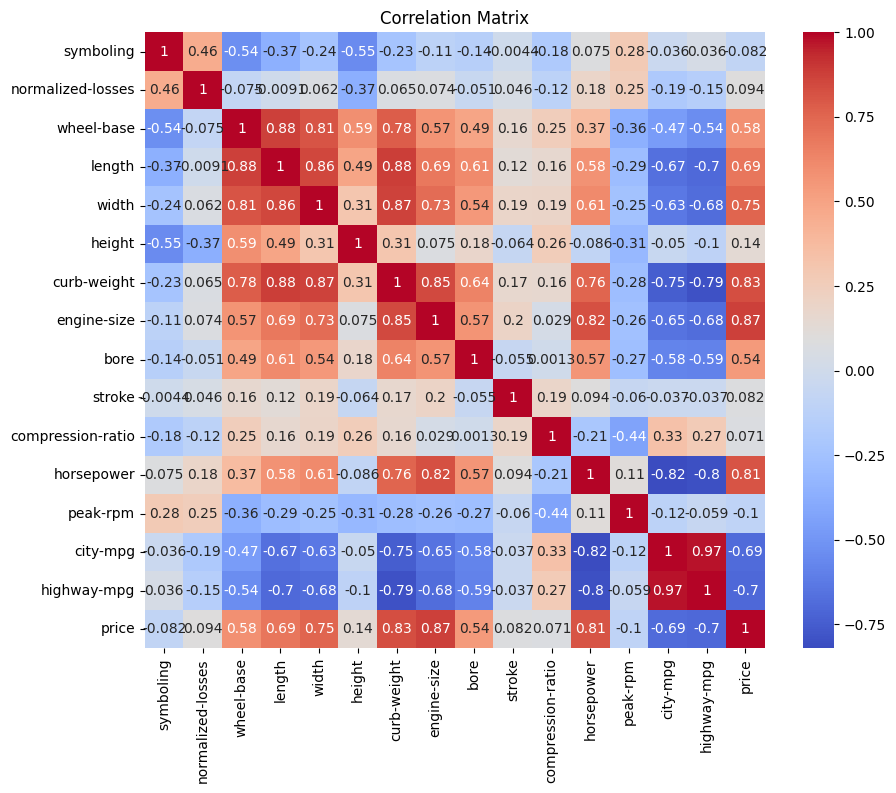

In [20]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

#visualisasi korelasi atribut numeric
#insight: atribut "engine-size" memiliki korelasi paling kuat dan atribut "compression-ratio" memiliki korelasi paling lemat

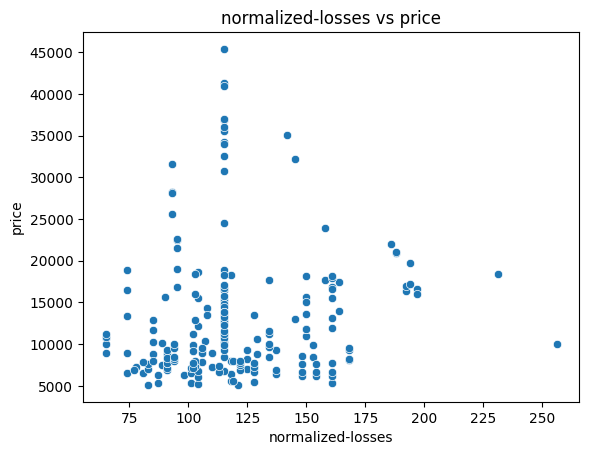

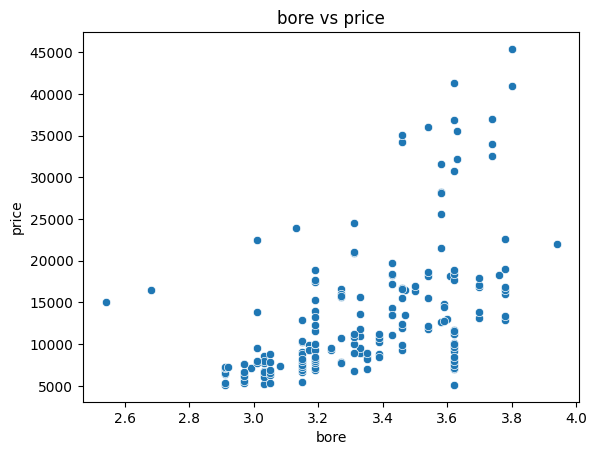

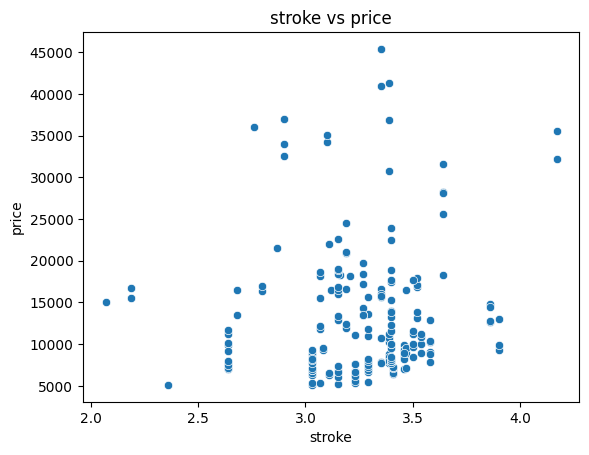

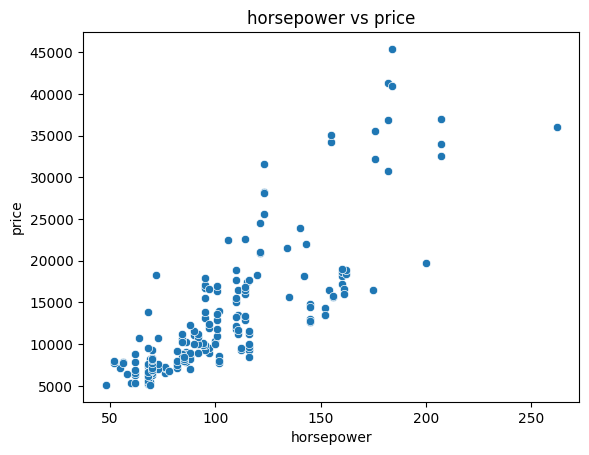

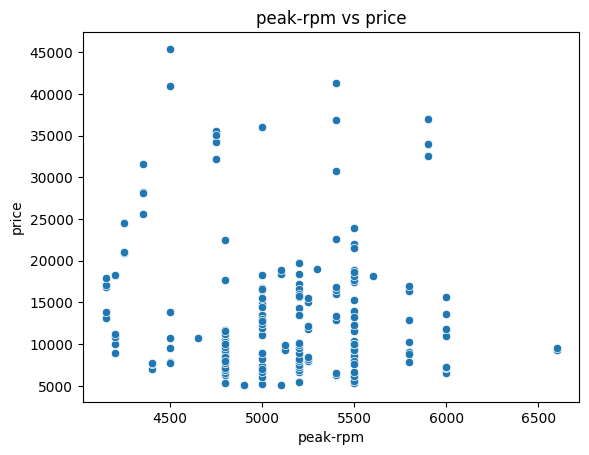

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

target = "price"

for col in num_cols:
    if col != target:
        plt.figure()
        sns.scatterplot(x=df[col], y=df[target])
        plt.title(f"{col} vs {target}")
        plt.xlabel(col)
        plt.ylabel(target)
        plt.show()

#membandingkan atribut target dengan atribut numeric untuk melihat visualisasi korelasi

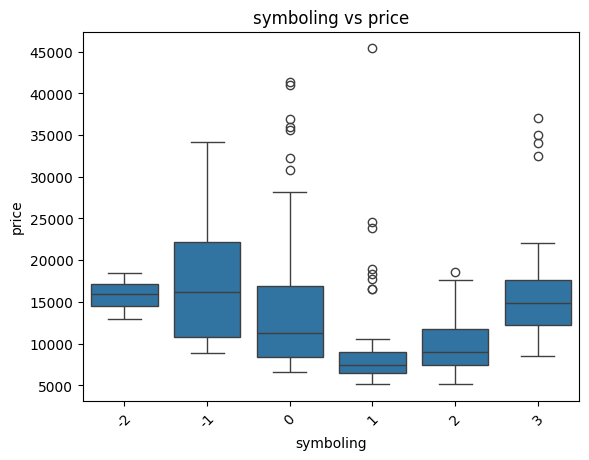

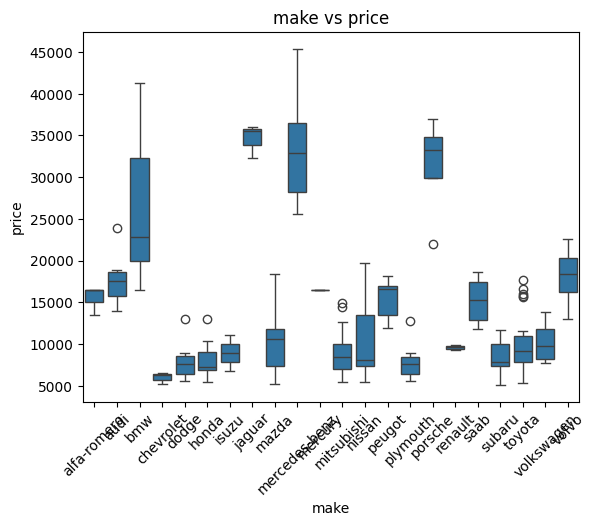

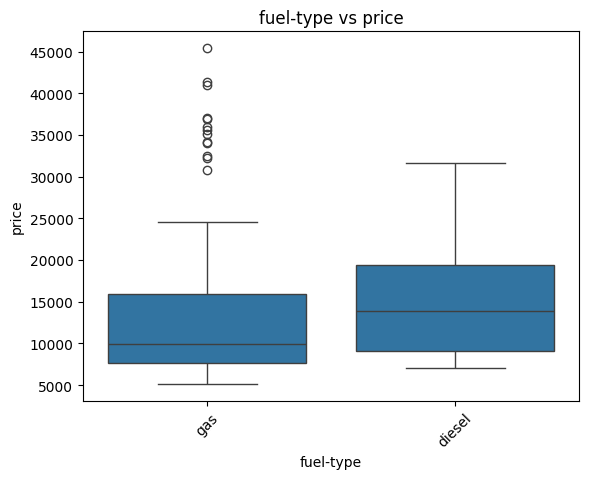

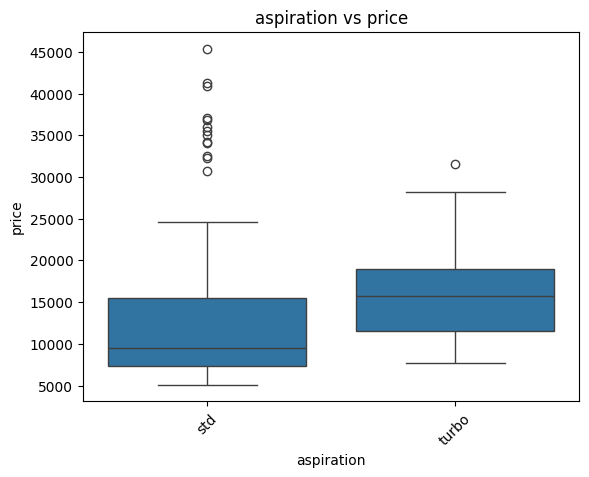

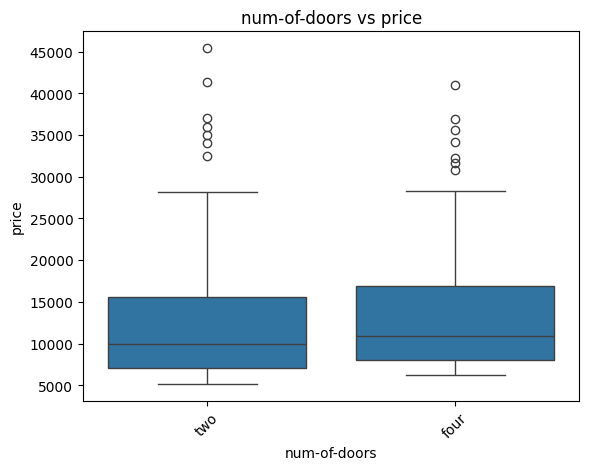

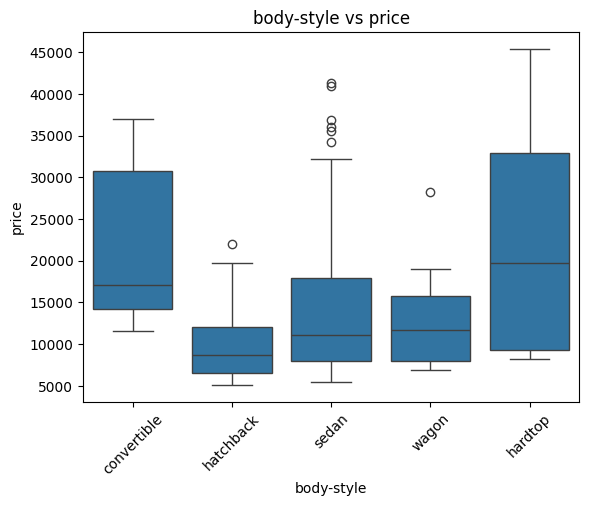

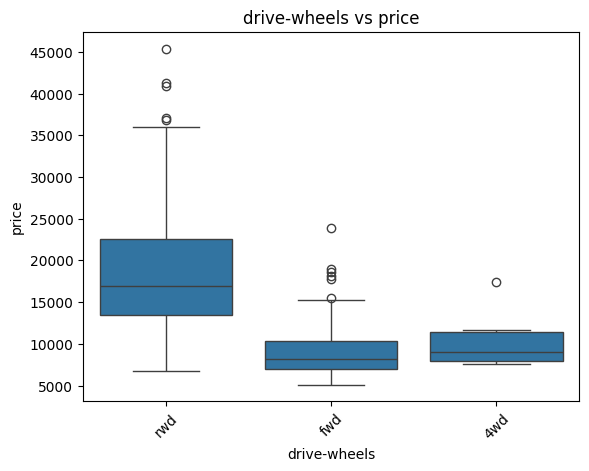

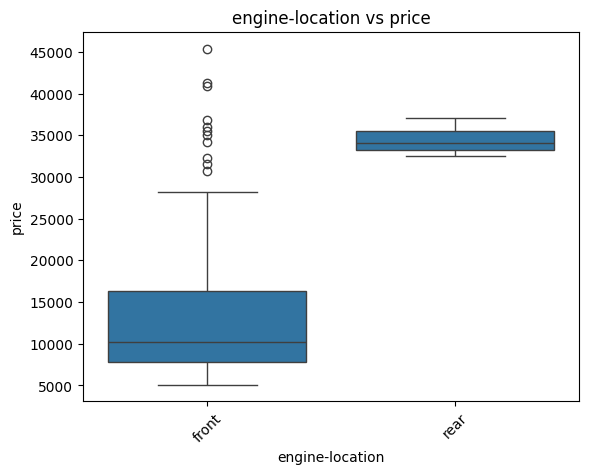

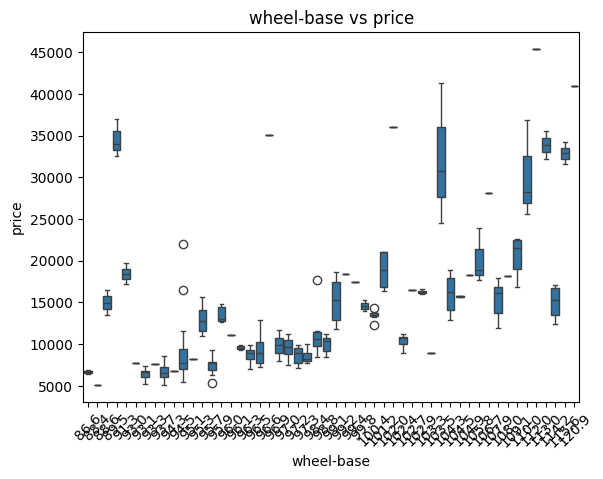

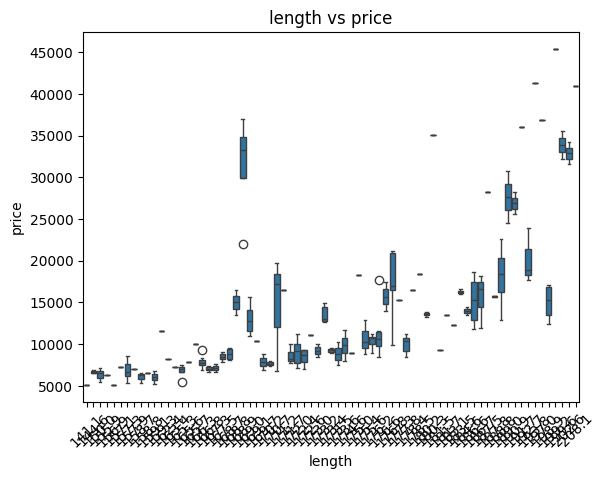

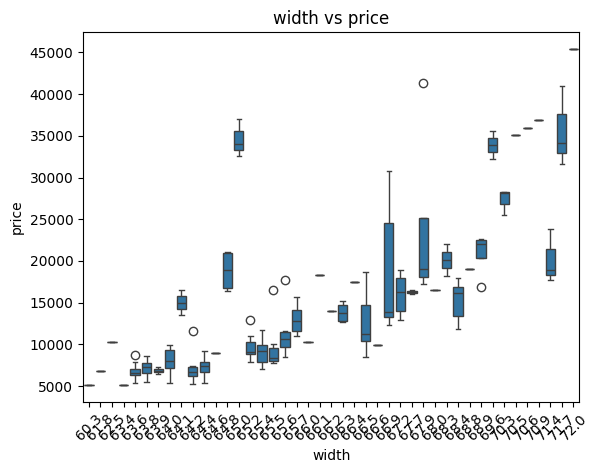

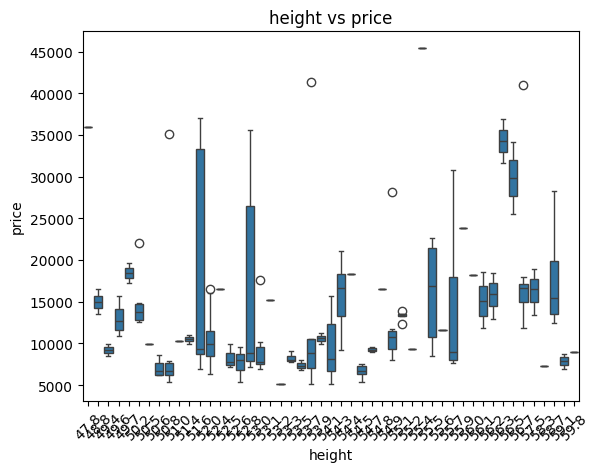

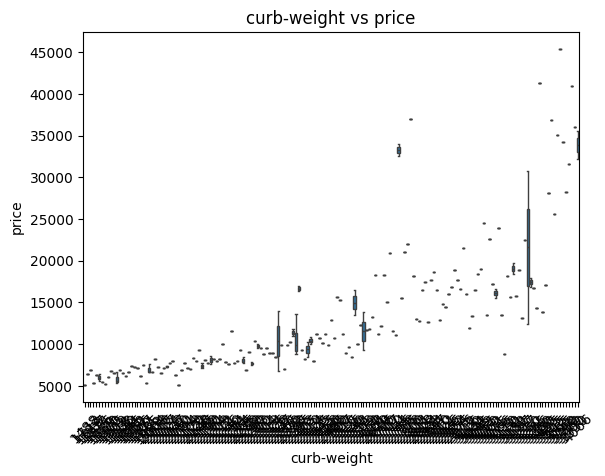

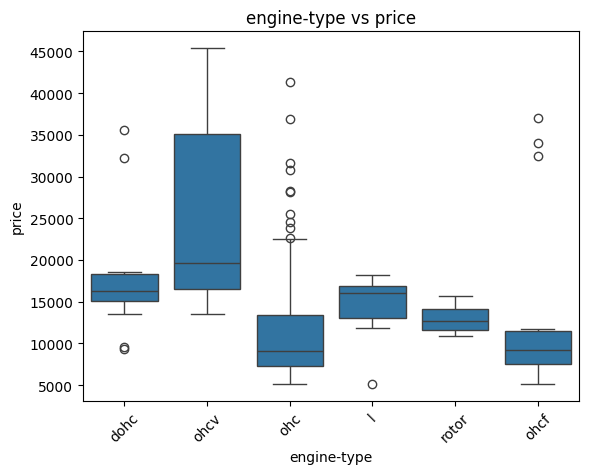

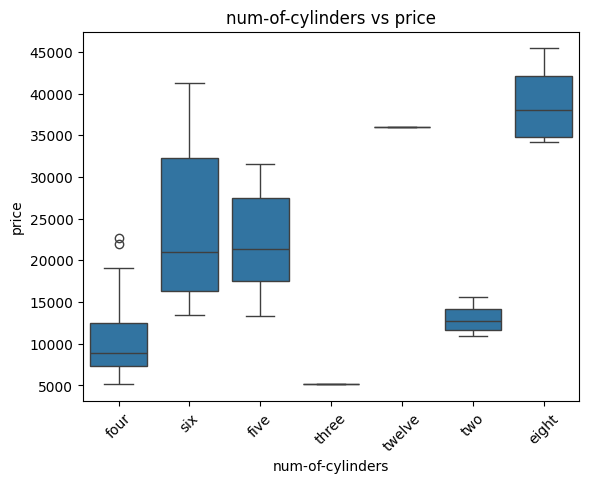

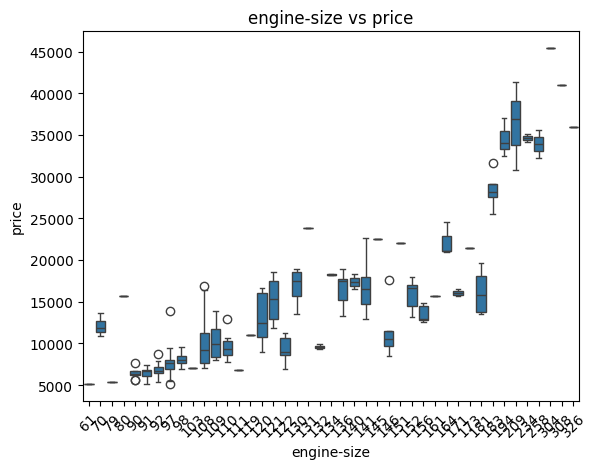

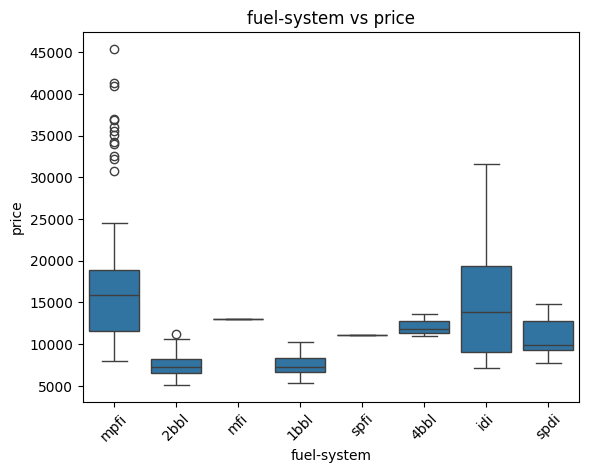

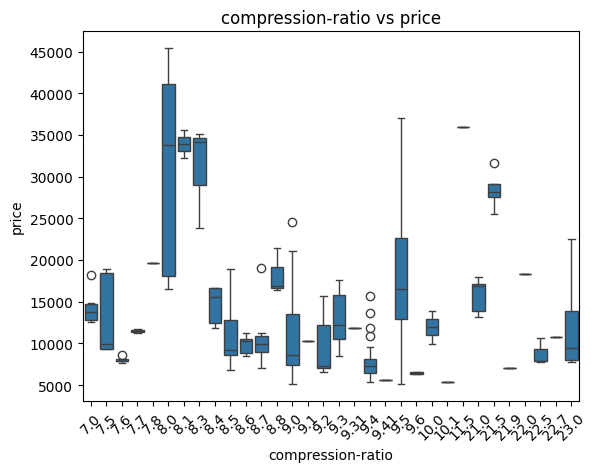

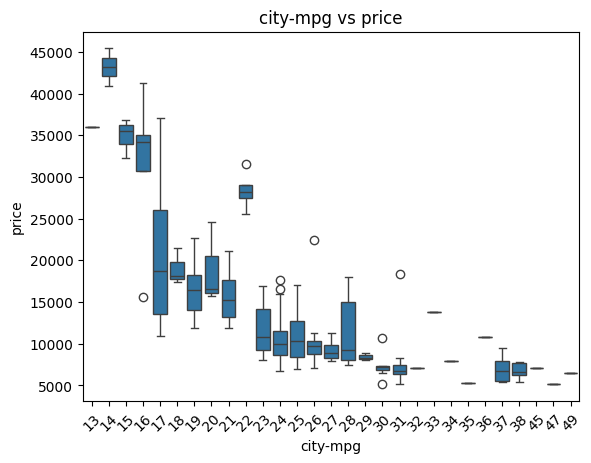

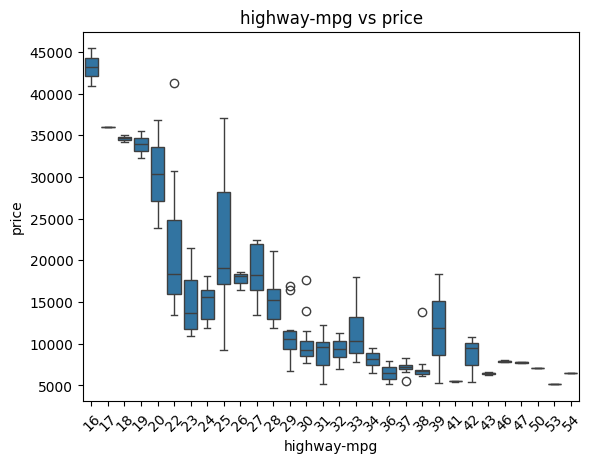

In [22]:
for col in cat_cols:
    plt.figure()
    sns.boxplot(x=df[col], y=df[target])
    plt.title(f"{col} vs {target}")
    plt.xticks(rotation=45)
    plt.show()

#membandingkan atribut target dengan atribut kategorik untuk melihat perbandingan antar kelas disetiap atribut, distribusi target, serta outlier

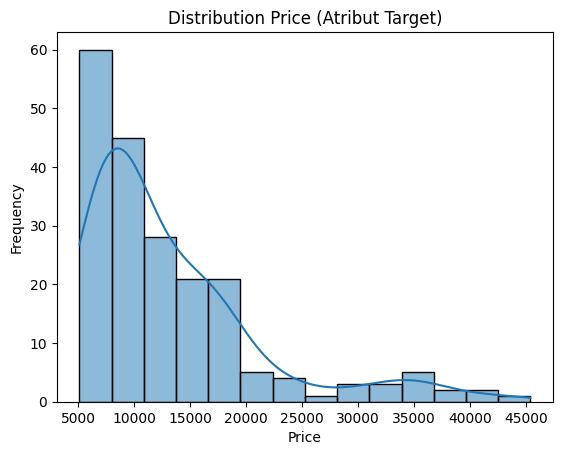

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["price"], kde=True)
plt.title("Distribution Price (Atribut Target)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

#visualisasi distribusi atribut target
#insight: atribut target memiliki distribusi skew kanan, perlu transformasi


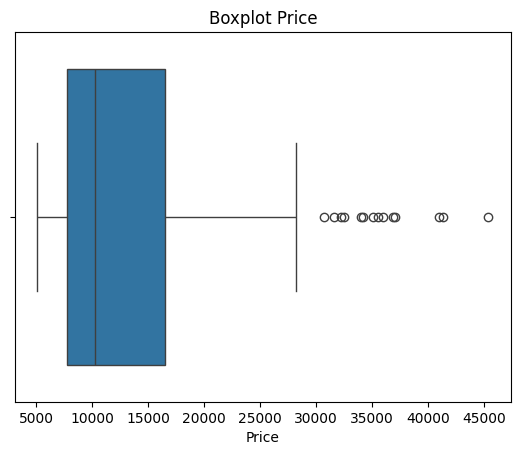

In [ ]:
sns.boxplot(x=df["price"])
plt.title("Boxplot Price")
plt.xlabel("Price")
plt.show()

#visualisasi boxplot atribut target
#insight: atribut target memiliki outlier, perlu transformasi

In [23]:
import numpy as np

df["price_log"] = np.log1p(df["price"])

#transformasi atribut target agar berdistribusi normal

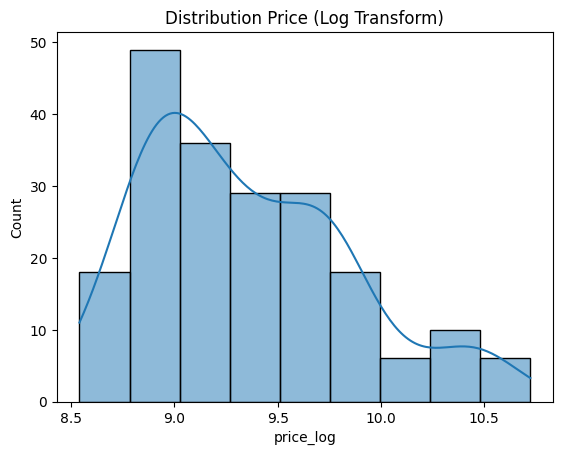

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["price_log"], kde=True)
plt.title("Distribution Price (Log Transform)")
plt.show()

#cek visualisasi hasil transformasi
#insight: distribusi atribut target cukup berubah menjadi berdistribusi normal walau tidah sempurna

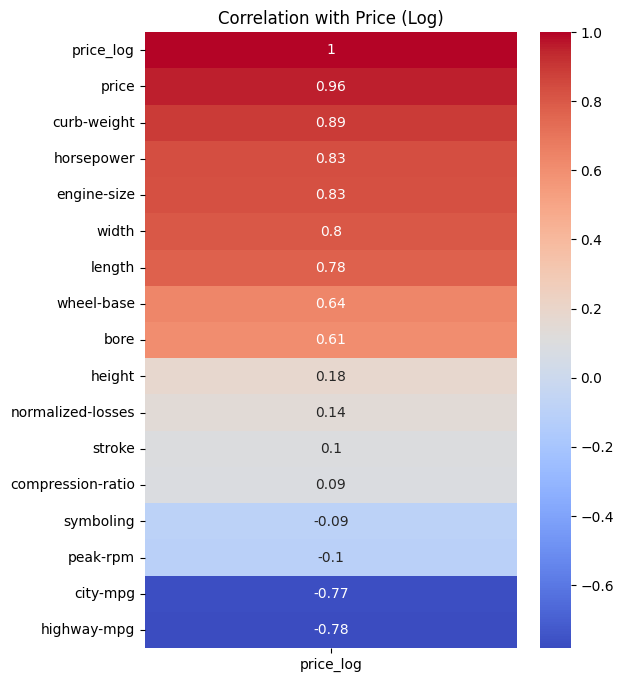

In [ ]:
corr = df.drop(columns=["price"]).corr(numeric_only=True)

corr = df.corr(numeric_only=True)

plt.figure(figsize=(6, 8))
sns.heatmap(corr[["price_log"]].sort_values(by="price_log", ascending=False),
            annot=True, cmap="coolwarm")
plt.title("Correlation with Price (Log)")
plt.show()

#visualisasi korelasi atribut numeric setelah transformasi
#insight: atribut "curb-weight" memiliki korelasi paling kuat dan atribut "highway-mpg" memiliki korelasi paling lemah

In [26]:
X = df.drop(["price", "price_log"], axis=1)
y = df["price_log"]
#memisahkan varibel X dan y

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
#memisahkan data train dan test

In [28]:
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# encoding dengan metode one-hot encoding

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

#menyamakan kolom train dan test

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#normalisasi data train menggunakan metode z-score

MODELLING

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model1 = Sequential([
    Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(16, activation="relu"),
    Dense(1)
])

#membangun model sederhana dengan 3 lapisan, menggunakan fungsi aktivasi relu

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model1.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

#menggunakan optimizer adam, loss func, mse, dan metric evaluasi mae

In [32]:
from tensorflow.keras.layers import Dense

model2 = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1)
])

#membangun model lebih medium dengan 4 lapisan, menggunakan fungsi aktivasi relu

In [33]:
model2.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

#menggunakan optimizer adam, loss func, mse, dan metric evaluasi mae

In [34]:
from tensorflow.keras.layers import Dense, Dropout

model3 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    
    Dense(64, activation="relu"),
    Dropout(0.3),
    
    Dense(32, activation="relu"),
    
    Dense(1)
])

#membangun model lebih kompleks dengan 4 lapisan, menggunakan fungsi aktivasi relu, dan menggunakan dropout

In [35]:
model3.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

#menggunakan optimizer adam, loss func, mse, dan metric evaluasi mae

TRAINING

In [37]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    patience=10,
    restore_best_weights=True
)

history1 = model1.fit(X_train, y_train, validation_split=0.2,
                      epochs=200, batch_size=16,
                      callbacks=[early_stop])

#melakukan training model 1 dengan epoch dengan 50 iterasi, batch size 16, validation split 0.2, verbose 1 menunjukan menampilkan progres, dan menggunakan early_stop untuk menghentikan jika mulai terjadi overfiting

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 129.0116 - mae: 11.2847 - val_loss: 122.8234 - val_mae: 10.9953
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 105.1368 - mae: 10.1984 - val_loss: 115.9430 - val_mae: 10.6636
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 89.9999 - mae: 9.4447 - val_loss: 109.8321 - val_mae: 10.3527
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 79.0134 - mae: 8.8443 - val_loss: 104.0319 - val_mae: 10.0574
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 70.3403 - mae: 8.3332 - val_loss: 98.3297 - val_mae: 9.7602
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 62.2363 - mae: 7.8217 - val_loss: 92.6313 - val_mae: 9.4575
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 54.1715 - mae: 7.2670 - val_loss: 86.4983 - val_mae: 9.1205
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 45.8151 - mae: 6.6317 - val_loss: 80.3369 - val_mae: 8.7649
Epoch 9/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms

In [39]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    patience=10,
    restore_best_weights=True
)

history2 = model2.fit(X_train, y_train, validation_split=0.2,
                      epochs=200, batch_size=16,
                      callbacks=[early_stop])

#melakukan training model 2 dengan epoch dengan 50 iterasi, batch size 16, validation split 0.2, verbose 1 menunjukan menampilkan progres, dan menggunakan early_stop untuk menghentikan jika mulai terjadi overfiting

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 87.3756 - mae: 9.2880 - val_loss: 70.1938 - val_mae: 8.3166
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 54.4991 - mae: 7.3171 - val_loss: 53.1424 - val_mae: 7.2135
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 32.0602 - mae: 5.5539 - val_loss: 39.2548 - val_mae: 6.1358
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 14.1103 - mae: 3.5152 - val_loss: 27.1717 - val_mae: 4.9600
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.8585 - mae: 1.5837 - val_loss: 18.8585 - val_mae: 3.8700
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.4268 - mae: 1.2946 - val_loss: 15.7069 - val_mae: 3.3713
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8334 - mae: 1.1494 - val_loss: 15.9599 - val_mae: 3.4317
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.6273 - mae: 0.6091 - val_loss: 16.8600 - val_mae: 3.5843
Epoch 9/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.

In [40]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    patience=10,
    restore_best_weights=True
)

history3 = model3.fit(X_train, y_train, validation_split=0.2,
                      epochs=200, batch_size=16,
                      callbacks=[early_stop])

#melakukan training model 3 dengan epoch dengan 50 iterasi, batch size 16, validation split 0.2, verbose 1 menunjukan menampilkan progres, dan menggunakan early_stop untuk menghentikan jika mulai terjadi overfiting

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 69.3287 - mae: 8.2318 - val_loss: 52.7874 - val_mae: 7.2365
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 31.8266 - mae: 5.4111 - val_loss: 24.3701 - val_mae: 4.8459
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.7426 - mae: 2.5422 - val_loss: 7.6450 - val_mae: 2.4729
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 10.1719 - mae: 2.3865 - val_loss: 7.5459 - val_mae: 2.4751
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.1809 - mae: 1.7838 - val_loss: 11.2416 - val_mae: 3.1263
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.7690 - mae: 1.7591 - val_loss: 12.6124 - val_mae: 3.3528
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 3.8788 - mae: 1.6170 - val_loss: 10.2902 - val_mae: 2.9400
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 4.2870 - mae: 1.7294 - val_loss: 9.2453 - val_mae: 2.7091
Epoch 9/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 4.6132

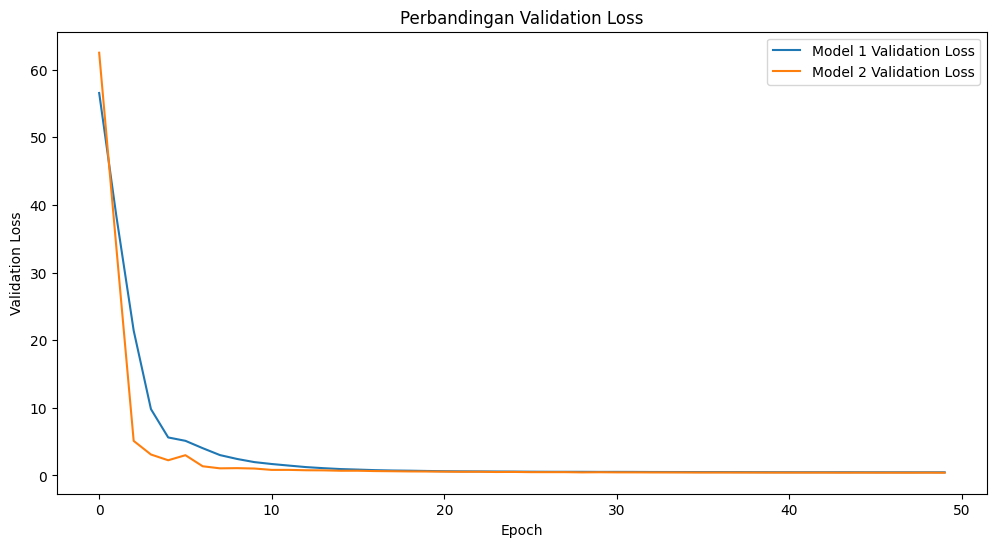

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(history1.history["val_loss"], label="Model 1 Validation Loss")
plt.plot(history2.history["val_loss"], label="Model 2 Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Perbandingan Validation Loss")
plt.legend()
plt.show()

#membandingkan visualisasi validation loss
#insight: kedua model belajar dengan baik karena terjadi penurunan val loss di awal yang signifikan dan kemudian stabil pada epoch selanjutnya
#insight: model 2 menunjukan performa lebih baik karena meiliki val loss lebih rendah dibandingkan model 1

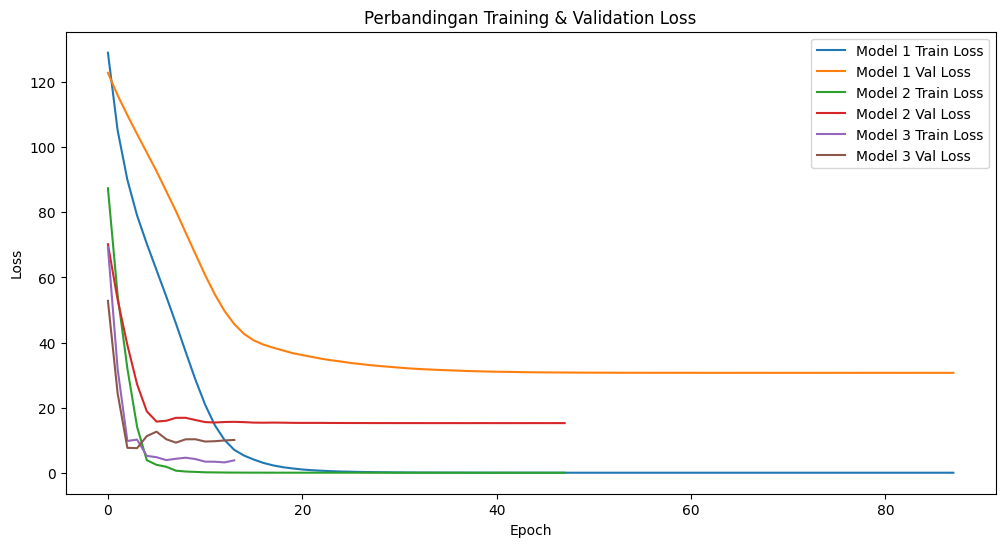

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Model 1
plt.plot(history1.history["loss"], label="Model 1 Train Loss")
plt.plot(history1.history["val_loss"], label="Model 1 Val Loss")

# Model 2
plt.plot(history2.history["loss"], label="Model 2 Train Loss")
plt.plot(history2.history["val_loss"], label="Model 2 Val Loss")

# Model 3
plt.plot(history3.history["loss"], label="Model 3 Train Loss")
plt.plot(history3.history["val_loss"], label="Model 3 Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Perbandingan Training & Validation Loss")
plt.legend()
plt.show()

#membandingkan visualisasi validation loss
#insight: model 1 mampu melakukan epoch paling banyak dan model 3 paling sedikit
#insight: ketiga model memiliki performa train lebih baik daripada val

EVALUASI

In [42]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred1 = model1.predict(X_test)
y_pred2 = model2.predict(X_test)
y_pred3 = model3.predict(X_test)
#melakukan prediksi dengan data test

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001ABF1349580> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


In [43]:
y_test_real = np.expm1(y_test)
y_pred1_real = np.expm1(y_pred1)
y_pred2_real = np.expm1(y_pred2)
y_pred3_real = np.expm1(y_pred3)

#mengembalikan nilai y yang sebelumnya berbentuk log menjadi nilai sesungguhnya menggunakan exp

In [ ]:
# MODEL 1
mae1 = mean_absolute_error(y_test_real, y_pred1_real)
rmse1 = np.sqrt(mean_squared_error(y_test_real, y_pred1_real))

# MODEL 2
mae2 = mean_absolute_error(y_test_real, y_pred2_real)
rmse2 = np.sqrt(mean_squared_error(y_test_real, y_pred2_real))

# MODEL 3
mae3 = mean_absolute_error(y_test_real, y_pred3_real)
rmse3 = np.sqrt(mean_squared_error(y_test_real, y_pred3_real))

# print hasil
print("Model 1 - MAE:", mae1)
print("Model 1 - RMSE:", rmse1)

print("Model 2 - MAE:", mae2)
print("Model 2 - RMSE:", rmse2)

print("Model 3 - MAE:", mae3)
print("Model 3 - RMSE:", rmse3)

#menghitung evaluasi 3 model dengan MAE dan RMSE
#insight: MAE model 1 paling kecil dari model lainnya
#insight: model 1 direkomendasikan karena bisa menangkap pola dengan lebi baik dalam kasus data ini

Model 1 - MAE: 11510.5011938665
Model 1 - RMSE: 15748.158535201472
Model 2 - MAE: 11678.235480517877
Model 2 - RMSE: 15921.546651131794
Model 3 - MAE: 30379.700418239685
Model 3 - RMSE: 89410.51038956511


Kesimpulan:
Model yang lebih kompleks tidak selalu lebih baik, terutama pada dataset kecil. Model sederhana cenderung lebih stabil dan mampu melakukan generalisasi dengan lebih baik, sementara model yang terlalu kompleks berisiko overfitting atau bahkan underfitting. Insight: pemilihan arsitektur model harus disesuaikan dengan karakteristik data, bukan sekadar dibuat semakin dalam. Namun hasil dari 3 model ini menujukan jika ketiga nya masih menghasilkan error yang besar sehingga masih belum cukup akurat. Hal ini kemungkinan disebabkan oleh keterbatasan jumlah data dan kompleksitas distribusi target.